# Planning Plots

In [23]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from simulation.trajectory_sampler import *
from envs import *
from policies import *
from data_processors import *
from scipy.stats import sem, t
import os


font = {'size'   : 13}
plt.rc('font', **font)  # pass in the font dict as kwargs



In [13]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# RESULTS

In [440]:
# Path principali per i risultati
paths = []

# Labels per i trial
lab = [
    "W=1",
    "W=2",
    "W=3",
    "W=5",
    "W=10",
    "P=1",
    "P=2",
    "P=3",
    "P=5",
    "P=10"
]

In [450]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=20)
    if performances.size > 0:
        all_performances.append(performances)

<Figure size 640x480 with 0 Axes>

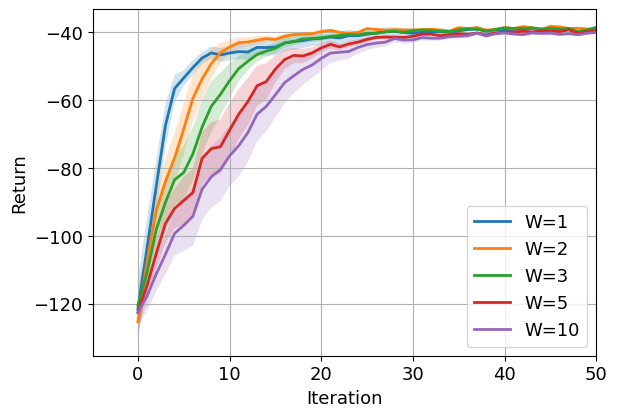

In [451]:
# Plot dei grafici
plt.clf()
plt.figure(figsize=(6.5, 4.5))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
# plt.title("Horizon 500")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend(loc="best")
plt.grid()
# plt.ylim(bottom=-80)
plt.xlim(right=50)
# Salva e mostra il grafico
plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()